# Factor-Based Equity Allocation Using Risk-Adjusted Growth Signals

### Author

K.Aakanksh Reddy

### Objective

Develop a systematic equity allocation framework that identifies high-quality compounders using only historical information and evaluate its performance against an equal-weight benchmark.

### Key Features

- Fully out-of-sample backtesting
- No look-ahead bias
- Rolling 252-day training window
- 21-day rebalancing interval
- Top-15 stock selection
- Inverse-volatility weighting
- Sharpe² × CAGR factor model

# Problem Statement

Most portfolio construction approaches fall into two categories:

1. Equal-weight investing, which treats all companies identically.
2. Prediction-based models, which attempt to forecast future returns.

This project explores an alternative approach.

Instead of predicting prices, stocks are ranked using historically observed quality and growth characteristics.

The hypothesis is that companies exhibiting strong risk-adjusted performance and sustainable compounding behavior will continue to outperform a broad equal-weight portfolio over long horizons.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize

In [4]:
stocks = [

# Banking & Financials
'HDFCBANK.NS',
'ICICIBANK.NS',
'SBIN.NS',
'KOTAKBANK.NS',
'AXISBANK.NS',
'BAJFINANCE.NS',
'BAJAJFINSV.NS',
'INDUSINDBK.NS',

# IT
'TCS.NS',
'INFY.NS',
'HCLTECH.NS',
'WIPRO.NS',
'TECHM.NS',

# Energy
'RELIANCE.NS',
'ONGC.NS',
'NTPC.NS',
'POWERGRID.NS',
'COALINDIA.NS',
'BPCL.NS',
'IOC.NS',
'GAIL.NS',

# FMCG
'HINDUNILVR.NS',
'ITC.NS',
'NESTLEIND.NS',
'BRITANNIA.NS',
'DABUR.NS',
'GODREJCP.NS',
'MARICO.NS',
'COLPAL.NS',

# Pharma
'SUNPHARMA.NS',
'DRREDDY.NS',
'CIPLA.NS',
'LUPIN.NS',
'AUROPHARMA.NS',

# Consumer
'TITAN.NS',
'ASIANPAINT.NS',
'BERGEPAINT.NS',
'PIDILITIND.NS',
'HAVELLS.NS',

# Auto
'MARUTI.NS',
'M&M.NS',
'BAJAJ-AUTO.NS',
'EICHERMOT.NS',
'HEROMOTOCO.NS',

# Metals
'TATASTEEL.NS',
'JSWSTEEL.NS',
'HINDALCO.NS',
'VEDL.NS',

# Industrials
'LT.NS',
'ABB.NS',
'BEL.NS',
'SIEMENS.NS',
'CUMMINSIND.NS',
'THERMAX.NS',
'CONCOR.NS',

# Telecom
'BHARTIARTL.NS',

# Cement
'ULTRACEMCO.NS',
'SHREECEM.NS',
'ACC.NS',
'AMBUJACEM.NS',

# Healthcare
'APOLLOHOSP.NS'
]
data = yf.download(stocks, start='2010-01-01', end='2024-01-01')['Close']

data = data.dropna(axis=1, how='all')

print(f"\nValid Stocks: {len(data.columns)}")
print(list(data.columns))

[*********************100%***********************]  61 of 61 completed



Valid Stocks: 61
['ABB.NS', 'ACC.NS', 'AMBUJACEM.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AUROPHARMA.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJAJFINSV.NS', 'BAJFINANCE.NS', 'BEL.NS', 'BERGEPAINT.NS', 'BHARTIARTL.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'COLPAL.NS', 'CONCOR.NS', 'CUMMINSIND.NS', 'DABUR.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GAIL.NS', 'GODREJCP.NS', 'HAVELLS.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS', 'INFY.NS', 'IOC.NS', 'ITC.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'LUPIN.NS', 'M&M.NS', 'MARICO.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'NTPC.NS', 'ONGC.NS', 'PIDILITIND.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBIN.NS', 'SHREECEM.NS', 'SIEMENS.NS', 'SUNPHARMA.NS', 'TATASTEEL.NS', 'TCS.NS', 'TECHM.NS', 'THERMAX.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'VEDL.NS', 'WIPRO.NS']


(3242, 61)


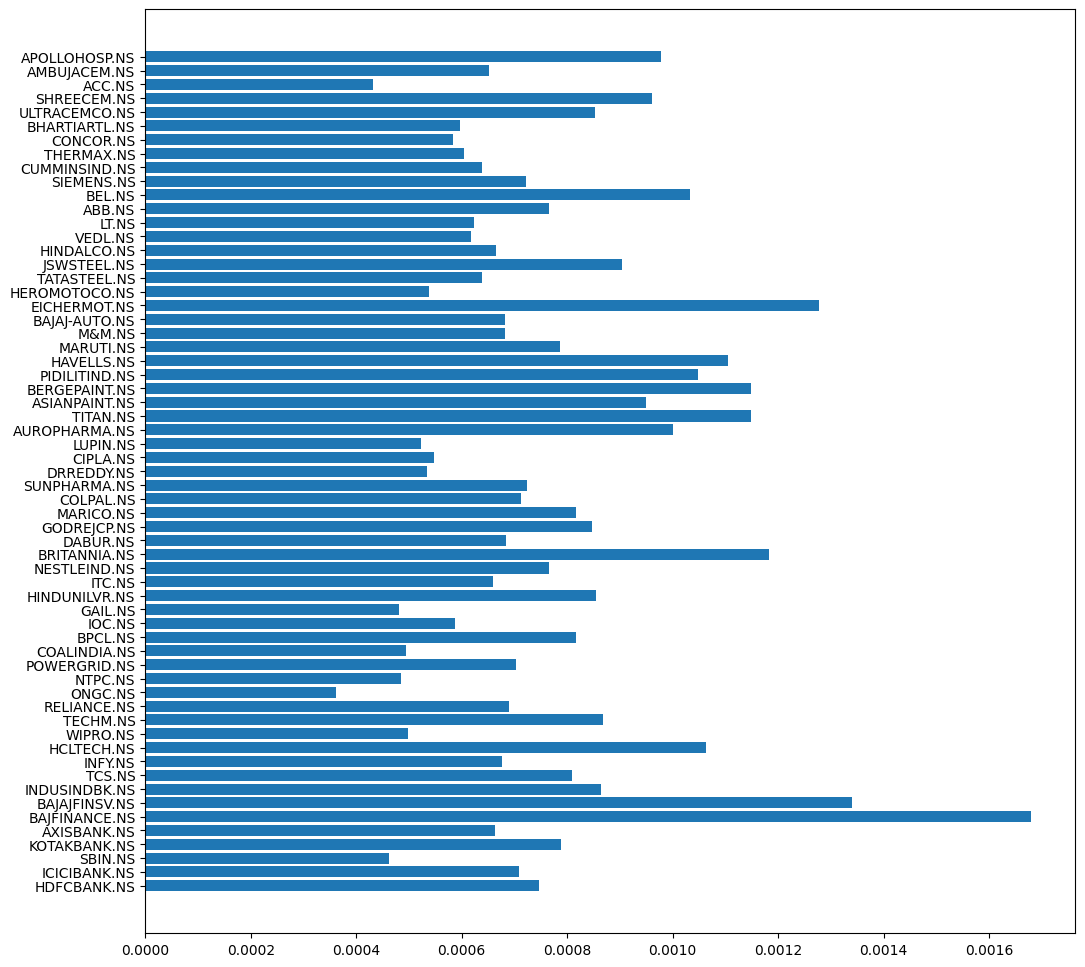

In [5]:
returns=data.pct_change().dropna()
print(returns.shape)
a=[]
for stock in stocks:
    r=np.mean(returns[stock])
    a.append(r)
plt.figure(figsize=(12,12))
plt.barh(stocks,a)
plt.show()

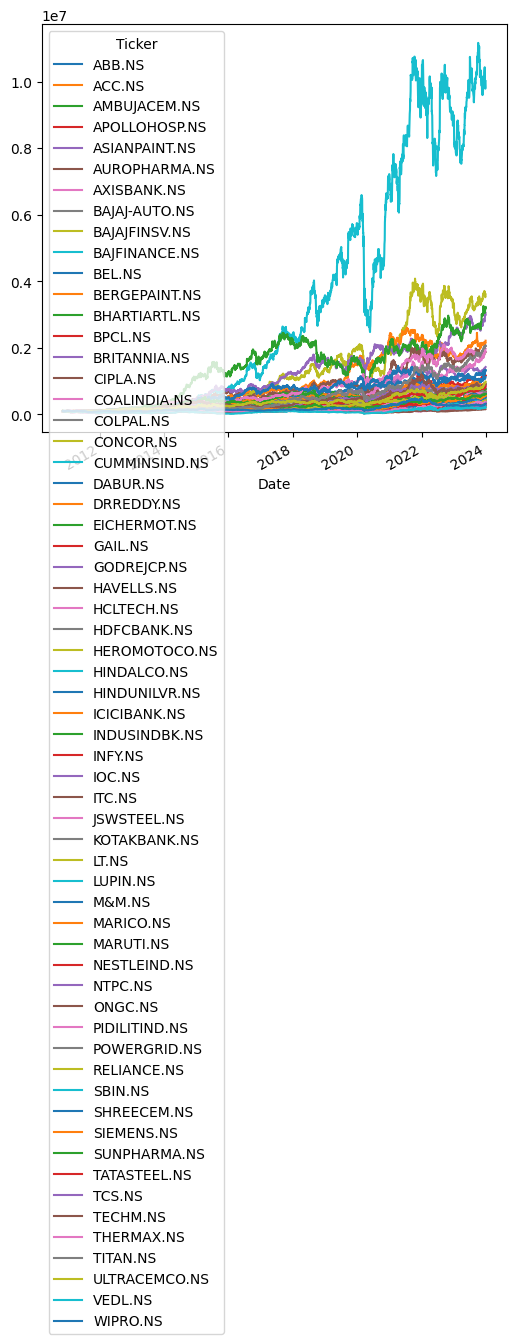

In [6]:
principal=100000
growth = (1 + returns).cumprod() * principal
growth.plot(figsize=(6,6))
plt.show()


Sharpe Ratios (Highest First)

Ticker
BAJFINANCE.NS    1.009
BRITANNIA.NS     0.934
EICHERMOT.NS     0.813
BAJAJFINSV.NS    0.810
PIDILITIND.NS    0.805
                 ...  
VEDL.NS          0.220
GAIL.NS          0.199
ACC.NS           0.177
SBIN.NS          0.167
ONGC.NS          0.096
Length: 61, dtype: float64


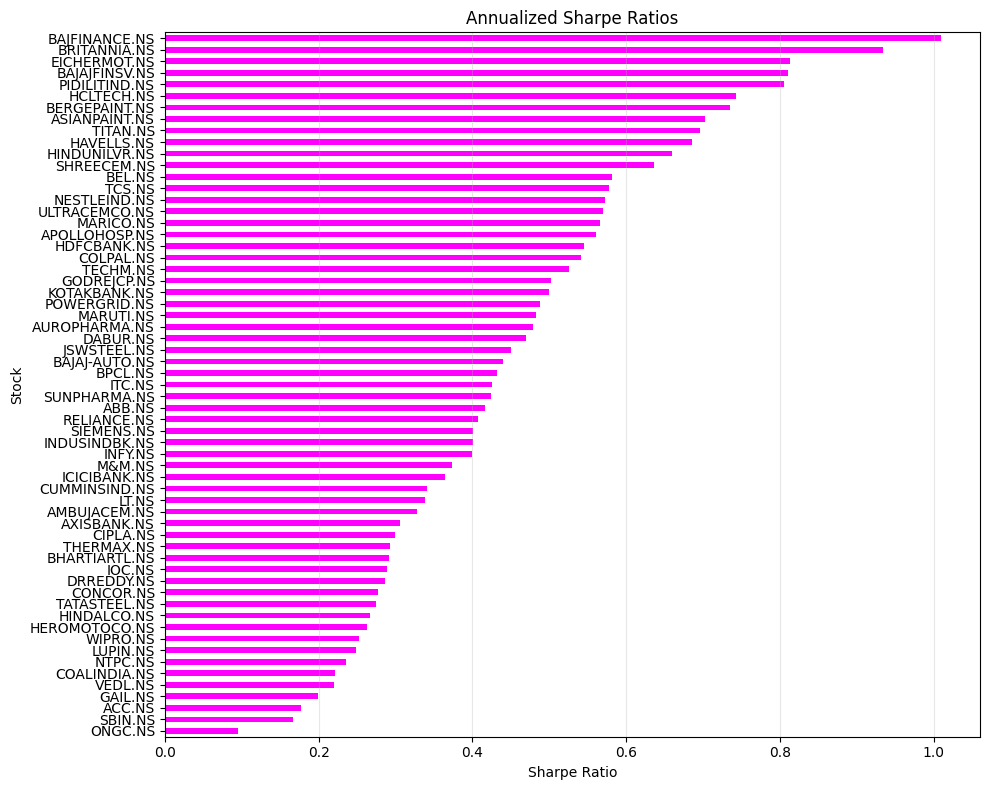

In [7]:
def sharpe(returns, risk_free_rate=0.06):
    
    excess_returns = returns - (risk_free_rate / 252)

    annual_excess_return = (excess_returns.mean() * 252)

    annual_volatility = (returns.std() * np.sqrt(252))

    sharpe_ratios = (annual_excess_return / annual_volatility.replace(0, np.nan))

    return sharpe_ratios


sharpes = sharpe(returns)


print("\nSharpe Ratios (Highest First)\n")
print(sharpes.sort_values(ascending=False).round(3))


plt.figure(figsize=(10, 8))

sharpes.sort_values().plot(kind='barh',color='magenta')

plt.title("Annualized Sharpe Ratios")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Stock")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
running_max = data.cummax()
drawdown = (data - running_max) / running_max
print(drawdown.min())

Ticker
ABB.NS          -0.526374
ACC.NS          -0.493899
AMBUJACEM.NS    -0.509911
APOLLOHOSP.NS   -0.394223
ASIANPAINT.NS   -0.286783
                   ...   
THERMAX.NS      -0.561296
TITAN.NS        -0.417300
ULTRACEMCO.NS   -0.374963
VEDL.NS         -0.859865
WIPRO.NS        -0.500158
Length: 61, dtype: float64


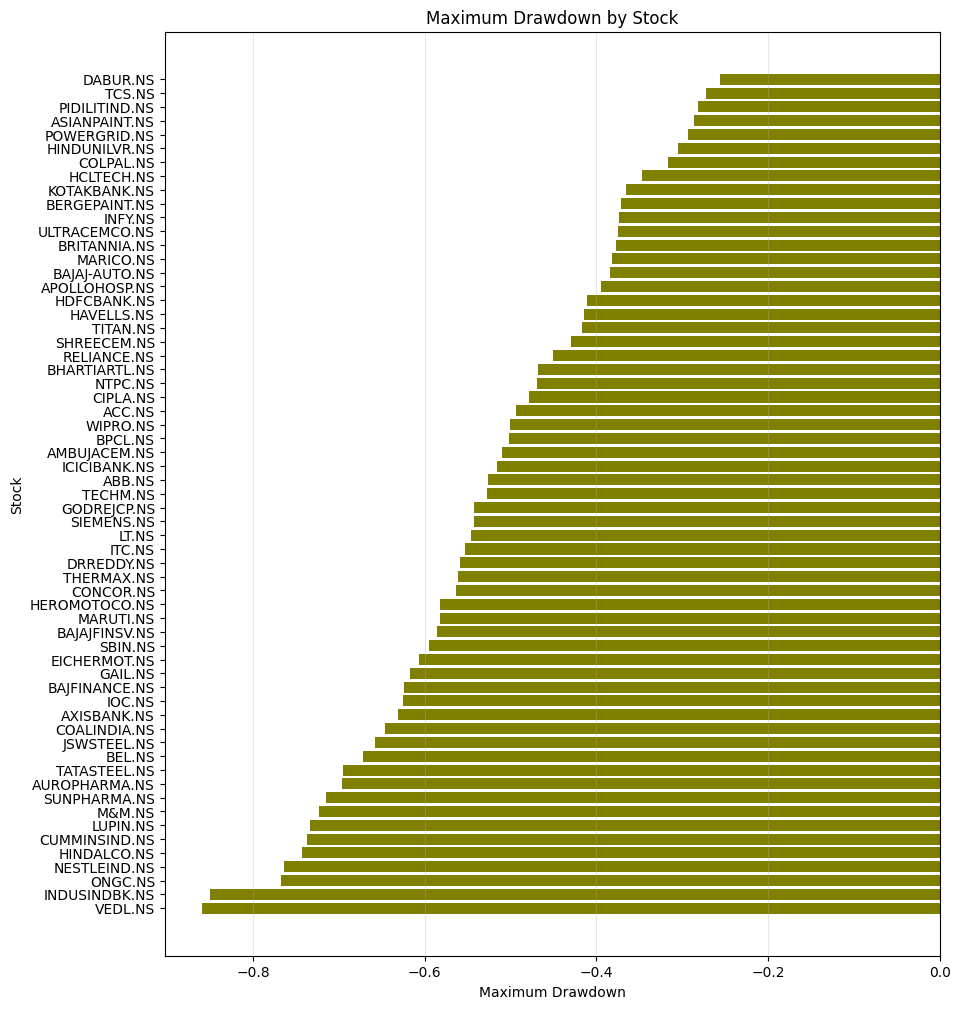

In [9]:
max_dd = drawdown.min().sort_values()

plt.figure(figsize=(10, 12))
plt.barh(max_dd.index, max_dd.values,color='olive')
plt.xlabel("Maximum Drawdown")
plt.ylabel("Stock")
plt.title("Maximum Drawdown by Stock")
plt.grid(axis='x', alpha=0.3)

plt.show()

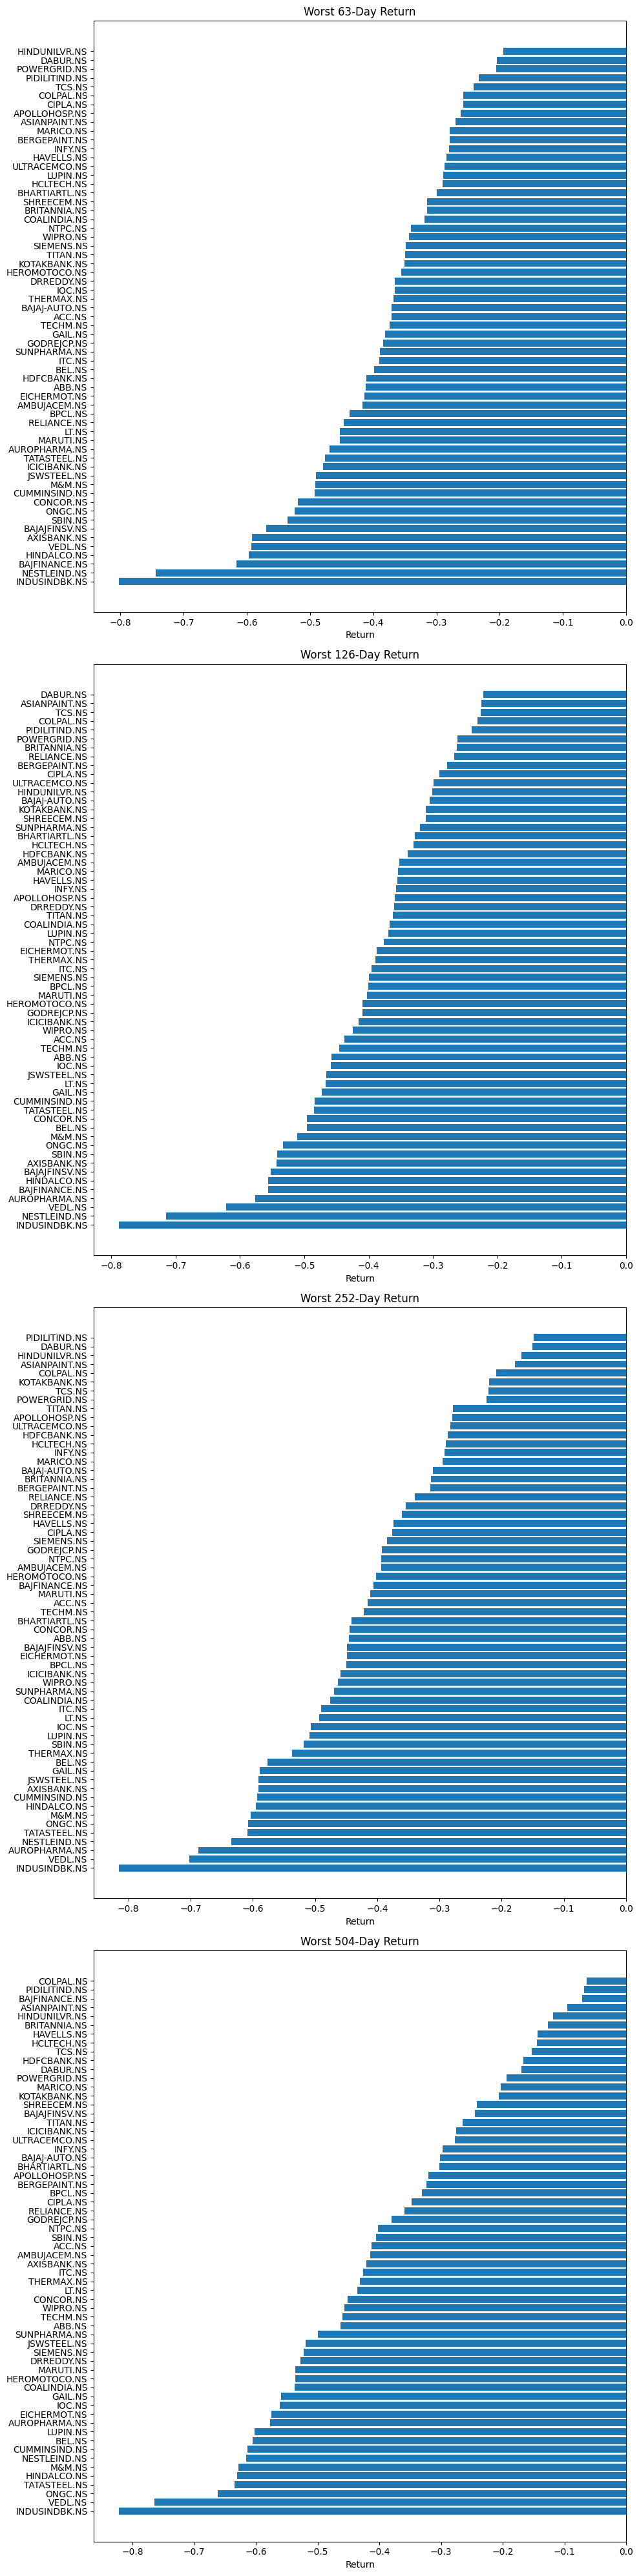

In [10]:
windows = [63, 126, 252, 504]

fig, axes = plt.subplots(
    len(windows),
    1,
    figsize=(10, 10 * len(windows))
)

for ax, window in zip(axes, windows):

    worst_declines = (
        data.pct_change(periods=window)
        .min()
        .sort_values()
    )

    ax.barh(
        worst_declines.index,
        worst_declines.values
    )

    ax.set_title(
        f"Worst {window}-Day Return"
    )

    ax.set_xlabel("Return")

plt.tight_layout()
plt.show()

# Methodology

The strategy follows a rolling walk-forward process.

For each rebalance date:

1. Use the previous 252 trading days as the training window.
2. Calculate CAGR and Sharpe ratio for every stock.
3. Compute the factor score:


Score = (Sharpe)^2 * CAGR


4. Select the Top 15 stocks.
5. Apply inverse-volatility scaling.
6. Normalize portfolio weights.
7. Hold for the next 21 trading days.
8. Repeat until the end of the dataset.

Only information available at the rebalance date is used when constructing the portfolio.

# Rolling Out-of-Sample Backtest

The strategy is evaluated using a walk-forward framework.

Training Window:
- 252 trading days

Holding Period:
- 21 trading days

Portfolio Construction:
- Sharpe² × CAGR score
- Top 15 stocks
- Inverse volatility weighting

Only historical information available at the rebalance date is used.

In [11]:
LOOKBACKS = [126, 252, 315, 504, 756]

all_results = {}
all_weight_histories = {}

for LOOKBACK in LOOKBACKS:

    print(f"Running {LOOKBACK}")

    REBALANCE = 21
    TOP_N = 15
    CAP = 0.35

    portfolio_returns = []
    portfolio_dates = []

    weight_history = []

    for i in range(
        LOOKBACK,
        len(returns)-REBALANCE,
        REBALANCE
    ):

        train = returns.iloc[
            i-LOOKBACK:i
        ]

        # FACTORS

        momentum = (
            (1 + train).prod() - 1
        )

        vol = (
            train.std()
            * np.sqrt(252)
        )

        sharpe_proxy = (
            momentum
            / vol.replace(0, np.nan)
        )

        score = (
            sharpe_proxy.rank(pct=True)
            * momentum.rank(pct=True)
        )

        score = score.fillna(0)

        if score.sum() == 0:
            continue

        inv_vol = (
            1 / vol.replace(0, np.nan)
        )

        valid = (
            score.index
            .intersection(
                inv_vol.dropna().index
            )
        )

        score = score.loc[valid]
        inv_vol = inv_vol.loc[valid]

        selected = score.nlargest(
            TOP_N
        )

        raw_weights = (
            selected
            * inv_vol.loc[
                selected.index
            ]
        )

        weights = (
            raw_weights
            / raw_weights.sum()
        )

        while weights.max() > CAP:

            capped = (
                weights > CAP
            )

            excess = (
                weights[capped]
                - CAP
            ).sum()

            weights[capped] = CAP

            uncapped = ~capped

            weights.loc[uncapped] += (
                weights.loc[uncapped]
                /
                weights.loc[uncapped].sum()
                * excess
            )

        weight_history.append(
            weights
        )

        future = (
            returns.iloc[
                i:i+REBALANCE
            ][selected.index]
        )

        future_returns = (
            future.dot(weights)
        )

        portfolio_returns.extend(
            future_returns.values
        )

        portfolio_dates.extend(
            future_returns.index
        )

    strategy_returns = pd.Series(
        portfolio_returns,
        index=portfolio_dates
    ).sort_index()

    all_results[
        LOOKBACK
    ] = strategy_returns

    all_weight_histories[
        LOOKBACK
    ] = weight_history

Running 126
Running 252
Running 315
Running 504
Running 756


# Performance Evaluation

The strategy is compared against an equal-weight benchmark using:

- Total Return
- CAGR
- Annualized Volatility
- Sharpe Ratio
- Maximum Drawdown

In [12]:
def performance_stats(daily_returns):

    daily_returns = daily_returns.dropna()

    if len(daily_returns) < 2:
        return pd.Series(dtype=float)

    years = (
        daily_returns.index[-1]
        - daily_returns.index[0]
    ).days / 365.25

    equity = (
        1 + daily_returns
    ).cumprod()

    total_return = (
        equity.iloc[-1] - 1
    ) * 100

    cagr = (
        equity.iloc[-1] ** (1 / years)
        - 1
    )

    vol = (
        daily_returns.std()
        * np.sqrt(252)
    )

    sharpe = np.nan

    if vol > 0:
        sharpe = (
            cagr - 0.06
        ) / vol

    drawdown = (
        equity / equity.cummax()
        - 1
    )

    max_dd = drawdown.min()

    calmar = np.nan

    if max_dd != 0:
        calmar = (
            cagr / abs(max_dd)
        )

    return pd.Series({

        "Years": round(years, 2),

        "Total Return (%)":
            round(total_return, 2),

        "CAGR (%)":
            round(cagr * 100, 2),

        "Vol (%)":
            round(vol * 100, 2),

        "Sharpe":
            round(sharpe, 2),

        "Max DD (%)":
            round(max_dd * 100, 2),

        "Calmar":
            round(calmar, 2)
    })

In [13]:
equal_results = {}

for lookback, strat in all_results.items():

    equal_returns = (
        returns
        .loc[strat.index]
        .mean(axis=1)
    )

    equal_results[lookback] = performance_stats(
        equal_returns
    )

equal_comparison = pd.DataFrame(
    equal_results
).T

print(equal_comparison)

     Years  Total Return (%)  CAGR (%)  Vol (%)  Sharpe  Max DD (%)  Calmar
126  12.60            995.05     20.91    15.34    0.97      -35.34    0.59
252  12.09           1020.12     22.13    15.35    1.05      -35.34    0.63
315  11.84            923.77     21.71    15.31    1.03      -35.34    0.61
504  11.07            787.29     21.81    15.50    1.02      -35.34    0.62
756  10.04            645.48     22.14    15.56    1.04      -35.34    0.63


In [14]:
comparison = pd.concat(
    [
        pd.DataFrame({
            f"Strategy ({lb})":
            performance_stats(strat),

            f"Equal Weight ({lb})":
            performance_stats(
                returns.loc[strat.index]
                .mean(axis=1)
            )
        }).T

        for lb, strat in all_results.items()
    ]
)

print(comparison.round(2))

                    Years  Total Return (%)  CAGR (%)  Vol (%)  Sharpe  \
Strategy (126)      12.60            920.78     20.24    17.01    0.84   
Equal Weight (126)  12.60            995.05     20.91    15.34    0.97   
Strategy (252)      12.09           1361.32     24.84    16.91    1.11   
Equal Weight (252)  12.09           1020.12     22.13    15.35    1.05   
Strategy (315)      11.84           1258.76     24.66    16.64    1.12   
Equal Weight (315)  11.84            923.77     21.71    15.31    1.03   
Strategy (504)      11.07           1143.59     25.58    16.92    1.16   
Equal Weight (504)  11.07            787.29     21.81    15.50    1.02   
Strategy (756)      10.04            773.18     24.08    17.05    1.06   
Equal Weight (756)  10.04            645.48     22.14    15.56    1.04   

                    Max DD (%)  Calmar  
Strategy (126)          -38.67    0.52  
Equal Weight (126)      -35.34    0.59  
Strategy (252)          -33.21    0.75  
Equal Weight (252)   

# Growth of Capital

Comparison of ₹1 invested in:

- History-Only Strategy
- Equal Weight Benchmark

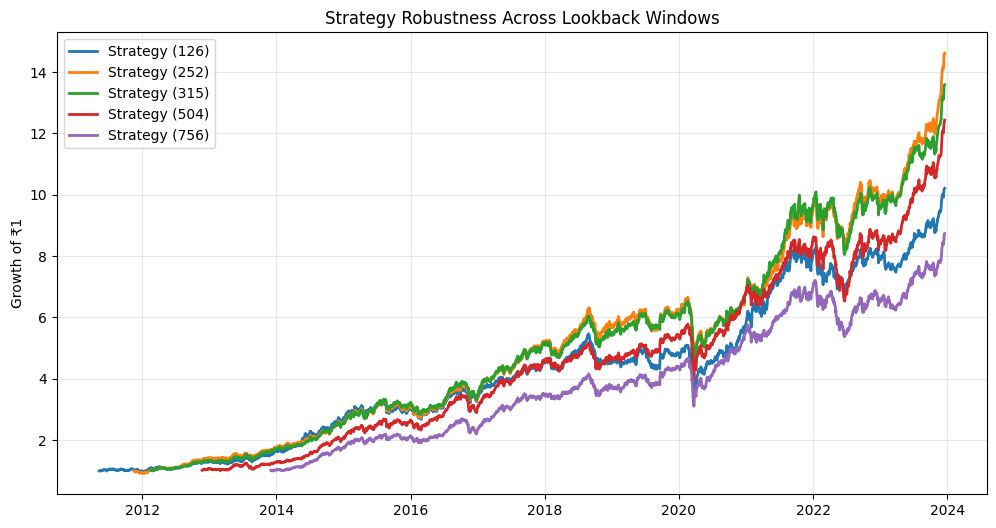

In [15]:
plt.figure(figsize=(12, 6))

for lookback, strat in all_results.items():

    strategy_growth = (
        1 + strat
    ).cumprod()

    plt.plot(
        strategy_growth,
        linewidth=2,
        label=f"Strategy ({lookback})"
    )

plt.title("Strategy Robustness Across Lookback Windows")
plt.ylabel("Growth of ₹1")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

# Portfolio Characteristics

To understand what drives performance,
average portfolio weights are computed
across all rebalance periods.


LOOKBACK = 126

Top Average Holdings

Ticker
BAJFINANCE.NS    0.033758
BRITANNIA.NS     0.033438
HINDUNILVR.NS    0.027257
EICHERMOT.NS     0.026695
BAJAJFINSV.NS    0.024615
SHREECEM.NS      0.024278
MARUTI.NS        0.023663
PIDILITIND.NS    0.021933
ITC.NS           0.021084
JSWSTEEL.NS      0.021015
INFY.NS          0.020394
TECHM.NS         0.020376
TITAN.NS         0.020106
INDUSINDBK.NS    0.019998
BERGEPAINT.NS    0.019869
dtype: float64


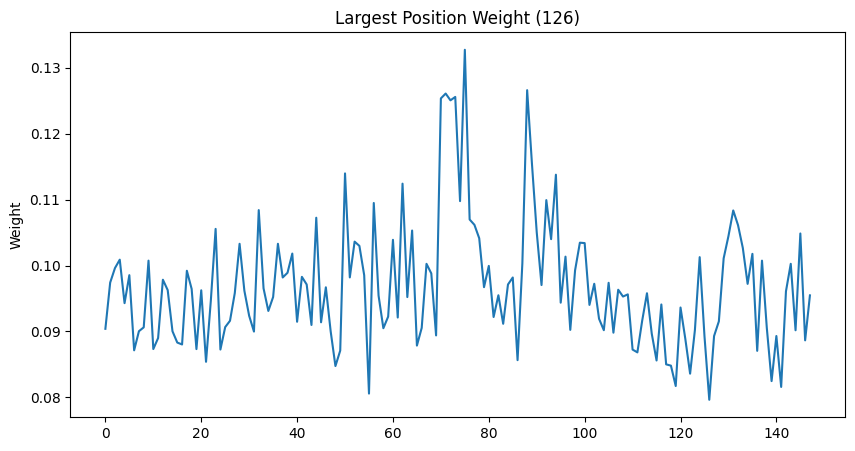

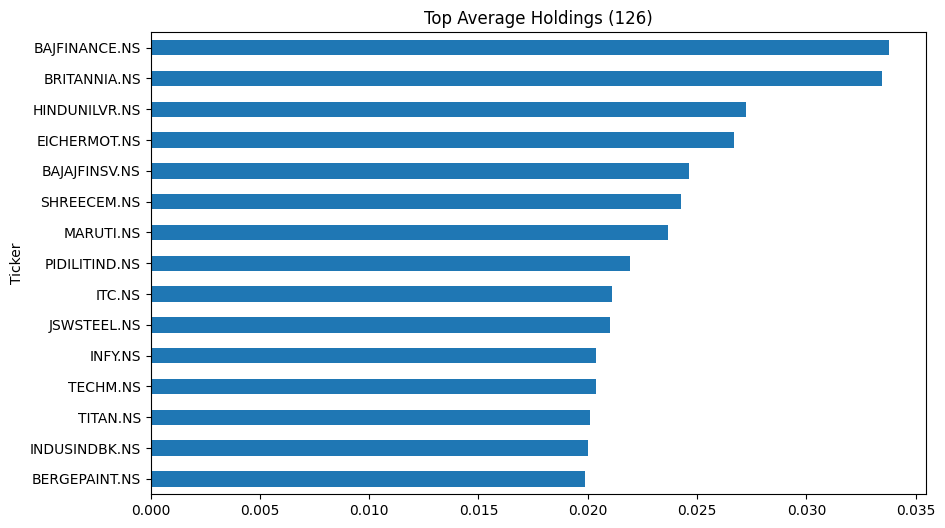


LOOKBACK = 252

Top Average Holdings

Ticker
BAJFINANCE.NS    0.039547
BRITANNIA.NS     0.036942
BAJAJFINSV.NS    0.033046
EICHERMOT.NS     0.030633
HINDUNILVR.NS    0.027403
SHREECEM.NS      0.027313
JSWSTEEL.NS      0.025179
PIDILITIND.NS    0.023988
MARUTI.NS        0.023814
SUNPHARMA.NS     0.022595
BERGEPAINT.NS    0.022141
TECHM.NS         0.022019
ITC.NS           0.021547
HDFCBANK.NS      0.020781
HCLTECH.NS       0.020292
dtype: float64


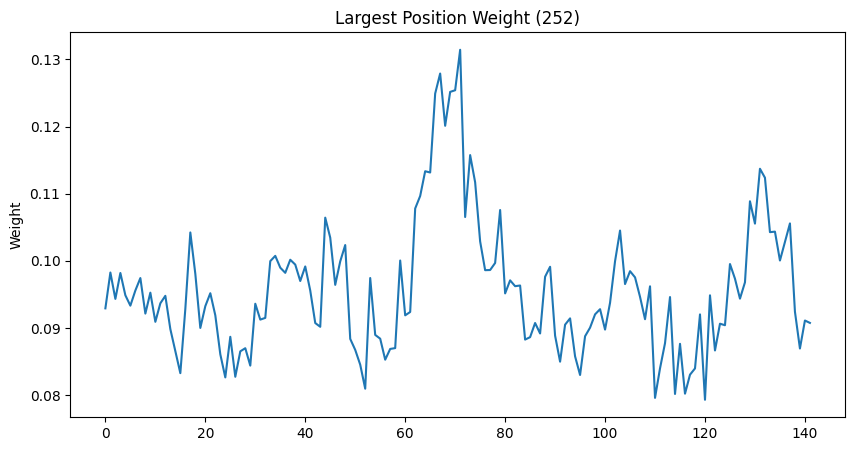

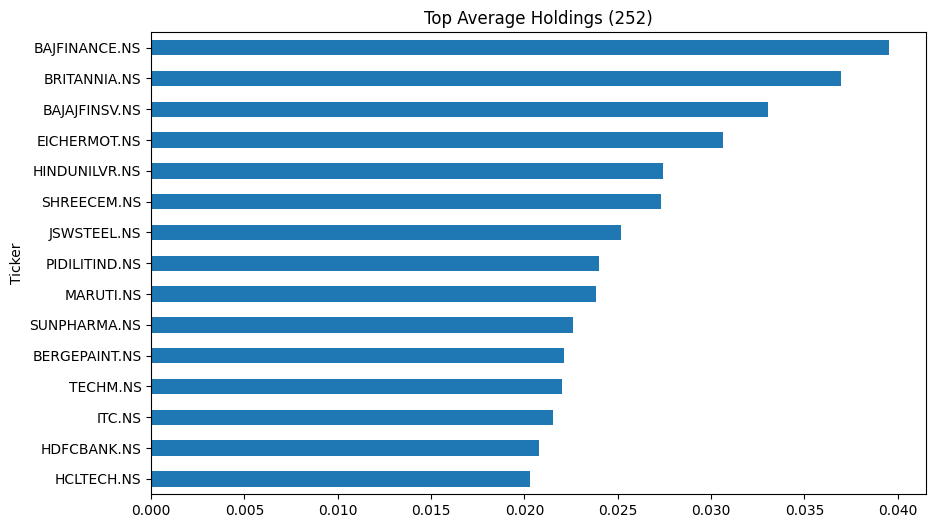


LOOKBACK = 315

Top Average Holdings

Ticker
BRITANNIA.NS     0.040707
BAJFINANCE.NS    0.039384
BAJAJFINSV.NS    0.032505
EICHERMOT.NS     0.029590
HINDUNILVR.NS    0.028173
SHREECEM.NS      0.027692
PIDILITIND.NS    0.026570
INDUSINDBK.NS    0.024423
BERGEPAINT.NS    0.024216
JSWSTEEL.NS      0.023278
MARUTI.NS        0.023042
ITC.NS           0.022824
HAVELLS.NS       0.022274
BEL.NS           0.021845
HDFCBANK.NS      0.021821
dtype: float64


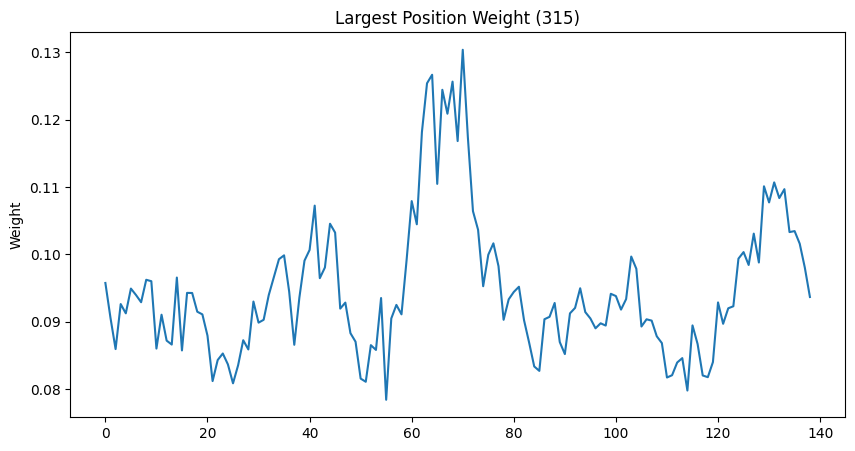

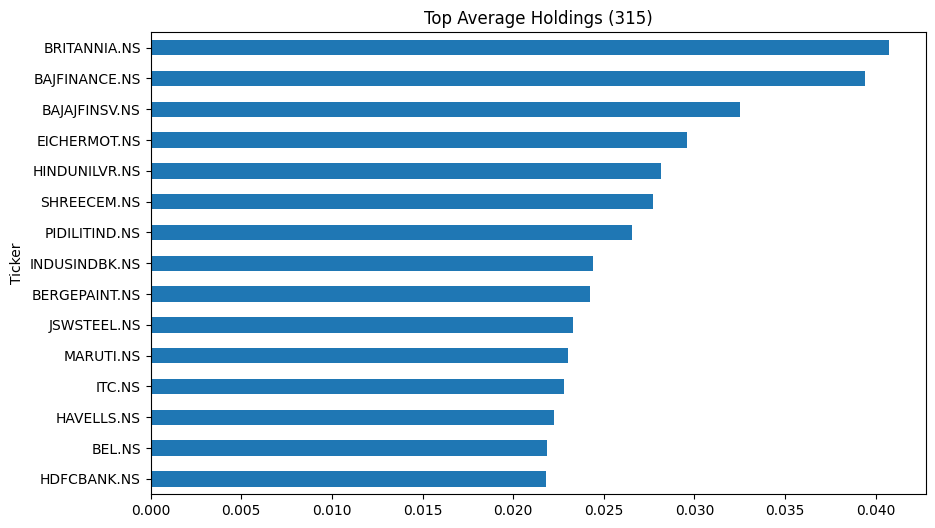


LOOKBACK = 504

Top Average Holdings

Ticker
BAJFINANCE.NS    0.045757
BRITANNIA.NS     0.036354
BERGEPAINT.NS    0.033983
BAJAJFINSV.NS    0.033699
PIDILITIND.NS    0.033110
SHREECEM.NS      0.031563
MARUTI.NS        0.030663
EICHERMOT.NS     0.029842
HINDUNILVR.NS    0.027175
HCLTECH.NS       0.027148
SUNPHARMA.NS     0.026190
HDFCBANK.NS      0.025517
TECHM.NS         0.025054
ASIANPAINT.NS    0.024284
BEL.NS           0.023852
dtype: float64


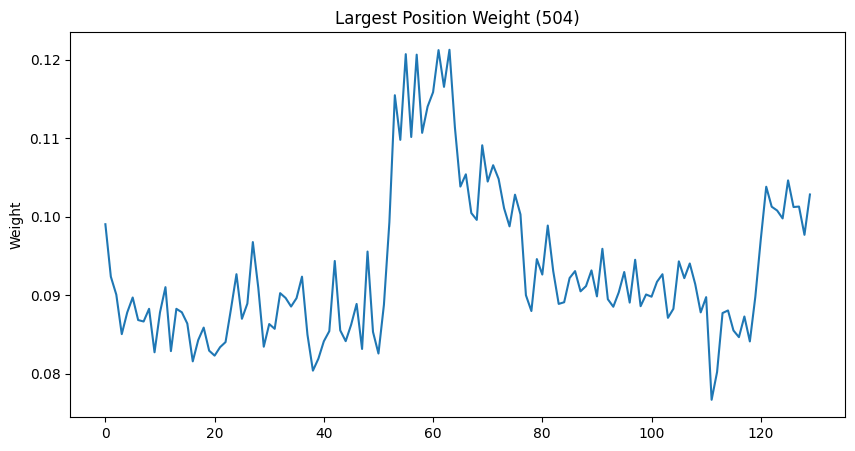

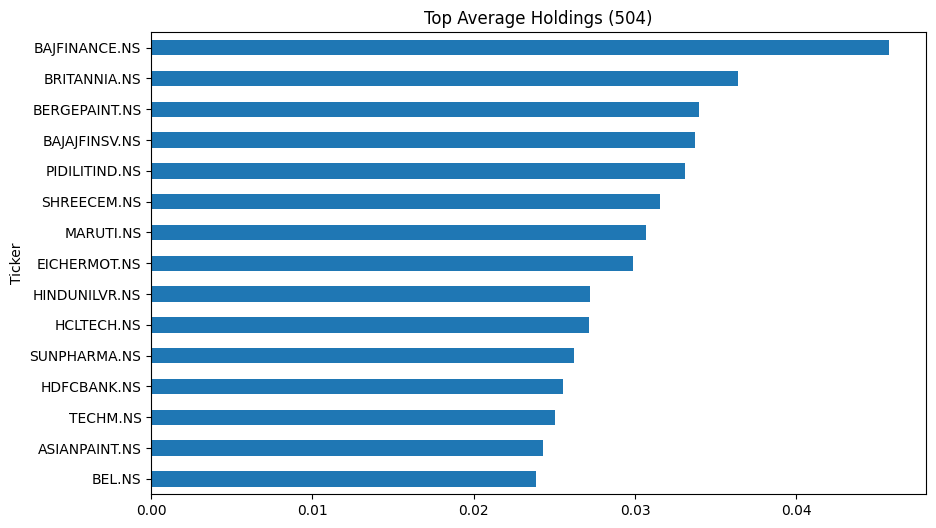


LOOKBACK = 756

Top Average Holdings

Ticker
BAJFINANCE.NS    0.052996
BRITANNIA.NS     0.051906
PIDILITIND.NS    0.049500
BERGEPAINT.NS    0.043112
HCLTECH.NS       0.033339
BAJAJFINSV.NS    0.033251
MARUTI.NS        0.031851
EICHERMOT.NS     0.031626
TITAN.NS         0.030998
HDFCBANK.NS      0.030569
HINDUNILVR.NS    0.029893
SHREECEM.NS      0.029371
RELIANCE.NS      0.027860
BEL.NS           0.027625
HAVELLS.NS       0.025791
dtype: float64


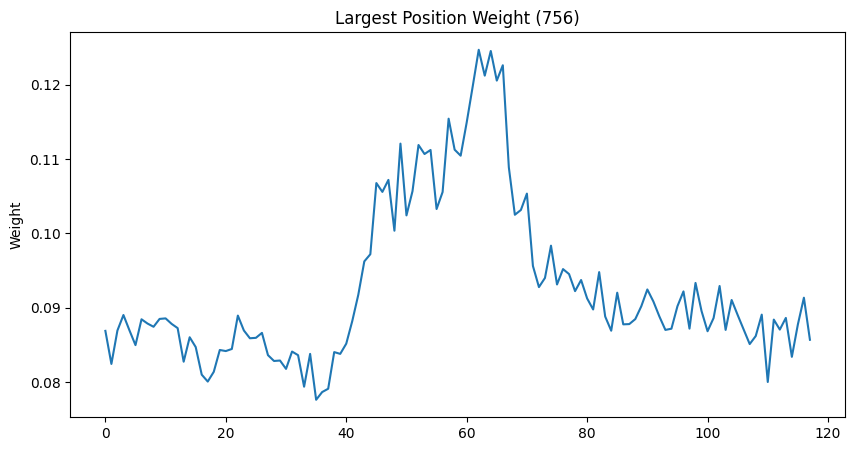

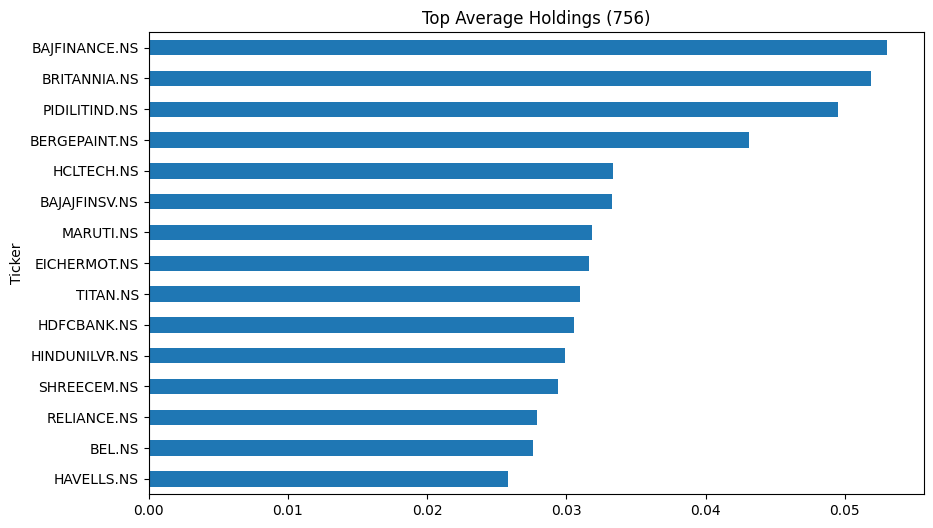

In [16]:
for lookback in LOOKBACKS:

    print("\n" + "="*80)
    print(f"LOOKBACK = {lookback}")
    print("="*80)

    weights_df = pd.DataFrame(
        all_weight_histories[lookback]
    ).fillna(0)

    avg_weights = (
        weights_df.mean()
        .sort_values(
            ascending=False
        )
    )

    print("\nTop Average Holdings\n")
    print(avg_weights.head(15))

    concentration = (
        weights_df.max(axis=1)
    )

    plt.figure(figsize=(10,5))

    plt.plot(
        concentration.values
    )

    plt.title(
        f"Largest Position Weight ({lookback})"
    )

    plt.ylabel("Weight")

    plt.show()

    plt.figure(figsize=(10,6))

    avg_weights.head(15)\
        .sort_values()\
        .plot(kind="barh")

    plt.title(
        f"Top Average Holdings ({lookback})"
    )

    plt.show()


LOOKBACK = 126
count    148.000000
mean       0.096882
std        0.009595
min        0.079618
25%        0.090177
50%        0.095946
75%        0.101287
max        0.132745
dtype: float64


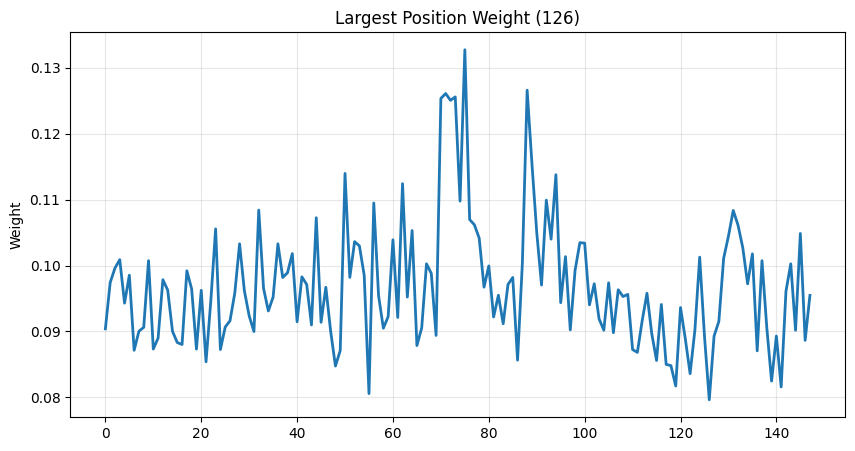


LOOKBACK = 252
count    142.000000
mean       0.095780
std        0.009977
min        0.079315
25%        0.089030
50%        0.094494
75%        0.099647
max        0.131434
dtype: float64


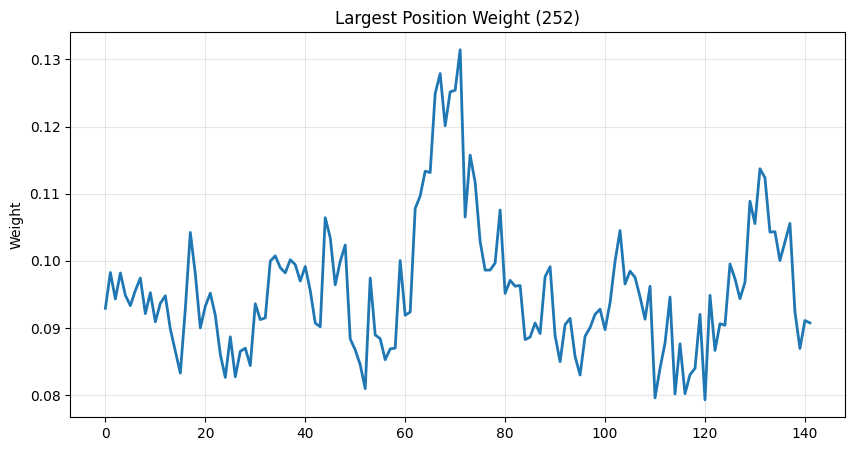


LOOKBACK = 315
count    139.000000
mean       0.094755
std        0.010346
min        0.078416
25%        0.087549
50%        0.092787
75%        0.099119
max        0.130374
dtype: float64


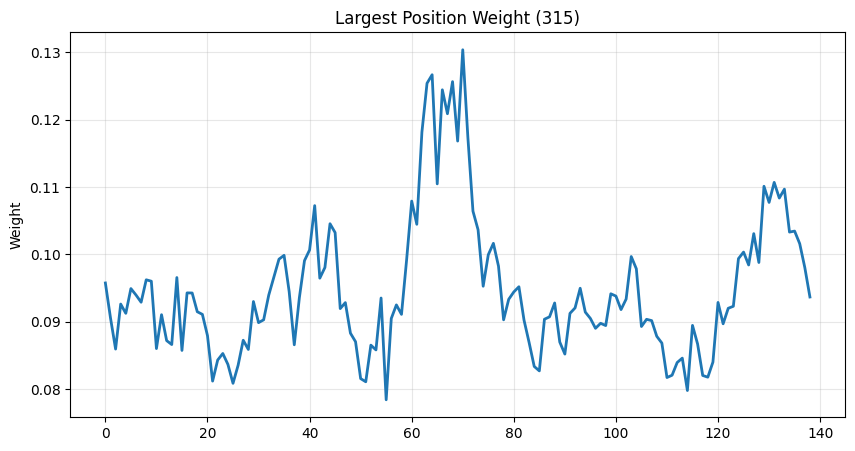


LOOKBACK = 504
count    130.000000
mean       0.093400
std        0.009650
min        0.076686
25%        0.087033
50%        0.090089
75%        0.099005
max        0.121268
dtype: float64


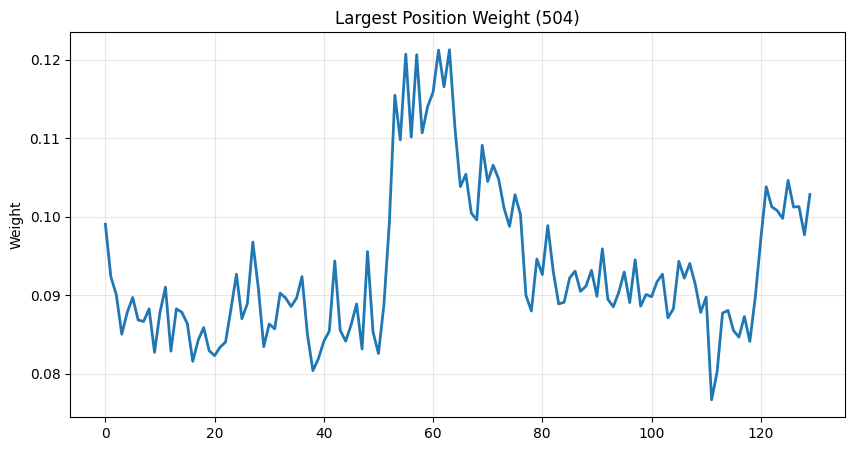


LOOKBACK = 756
count    118.000000
mean       0.092813
std        0.011012
min        0.077658
25%        0.086000
50%        0.088645
75%        0.095531
max        0.124679
dtype: float64


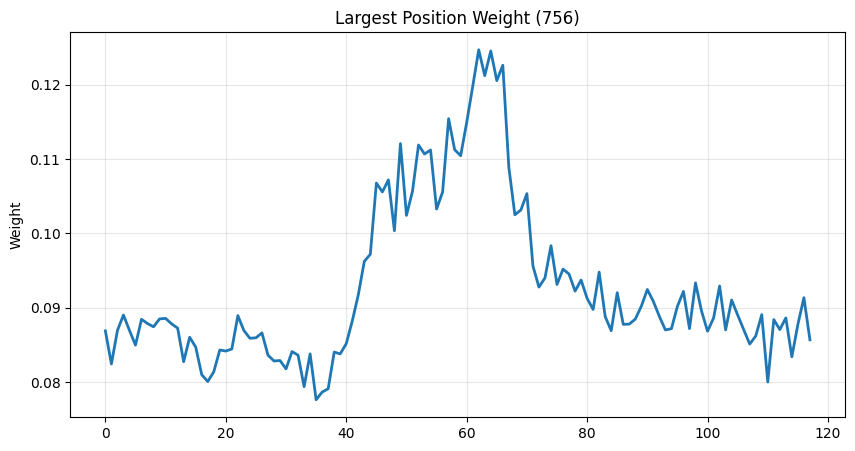

In [17]:
for lookback in LOOKBACKS:

    concentration = [
        w.max()
        for w in all_weight_histories[lookback]
    ]

    concentration = pd.Series(concentration)

    print("\n" + "="*80)
    print(f"LOOKBACK = {lookback}")
    print("="*80)

    print(concentration.describe())

    plt.figure(figsize=(10,5))

    plt.plot(
        concentration,
        linewidth=2,
        label=f"{lookback}"
    )

    plt.title(
        f"Largest Position Weight ({lookback})"
    )

    plt.ylabel("Weight")

    plt.grid(alpha=0.3)

    plt.show()

In [18]:
for i, w in enumerate(weight_history):
    if w.max() > 0.50:
        print(i)
        print(w.sort_values(ascending=False).head())
        print()



LOOKBACK ROBUSTNESS TEST
                    Years  Total Return (%)  CAGR (%)  Vol (%)  Sharpe  \
Strategy (126)      12.60            920.78     20.24    17.01    0.84   
Equal Weight (126)  12.60            995.05     20.91    15.34    0.97   
Nifty (126)         12.60            290.00     11.40    16.88    0.32   
Strategy (252)      12.09           1361.32     24.84    16.91    1.11   
Equal Weight (252)  12.09           1020.12     22.13    15.35    1.05   
Nifty (252)         12.09            323.89     12.69    16.69    0.40   
Strategy (315)      11.84           1258.76     24.66    16.64    1.12   
Equal Weight (315)  11.84            923.77     21.71    15.31    1.03   
Nifty (315)         11.84            309.26     12.64    16.57    0.40   
Strategy (504)      11.07           1143.59     25.58    16.92    1.16   
Equal Weight (504)  11.07            787.29     21.81    15.50    1.02   
Nifty (504)         11.07            294.83     13.21    16.63    0.43   
Strategy (7

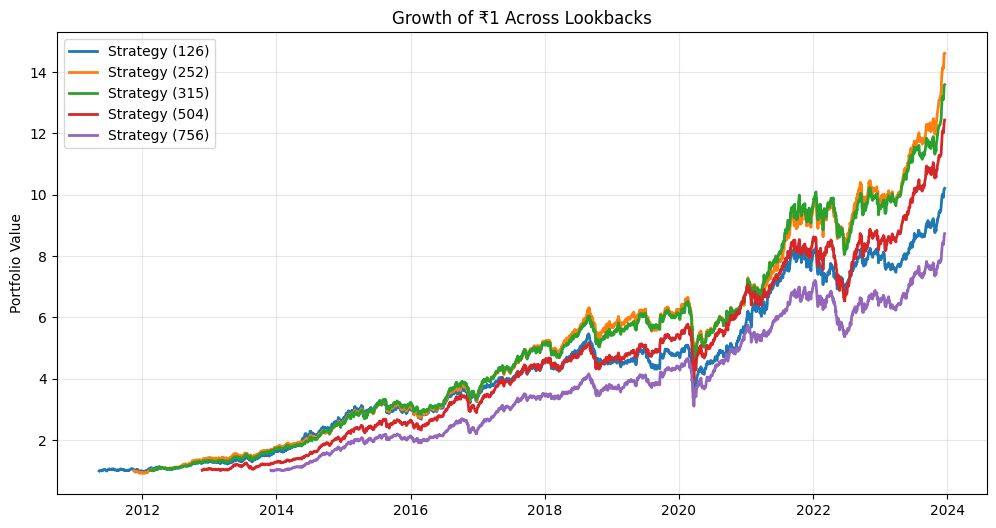

In [ ]:
# ==============================================================================
# NIFTY / EQUAL WEIGHT / STRATEGY COMPARISON
# ==============================================================================

nifty = yf.download(
    "^NSEI",
    start="2010-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

if isinstance(nifty, pd.DataFrame):
    nifty = nifty.squeeze()

nifty_returns = (
    nifty.pct_change()
    .dropna()
)

comparison_rows = []

plt.figure(figsize=(12,6))

for lookback, strat in all_results.items():

    equal = (
        returns
        .loc[strat.index]
        .mean(axis=1)
    )

    nifty_aligned = (
        nifty_returns
        .reindex(strat.index)
        .fillna(0)
    )

    comparison_rows.append(
        pd.Series(
            performance_stats(strat),
            name=f"Strategy ({lookback})"
        )
    )

    comparison_rows.append(
        pd.Series(
            performance_stats(equal),
            name=f"Equal Weight ({lookback})"
        )
    )

    comparison_rows.append(
        pd.Series(
            performance_stats(nifty_aligned),
            name=f"Nifty ({lookback})"
        )
    )

    strategy_growth = (
        1 + strat
    ).cumprod()

    plt.plot(
        strategy_growth,
        linewidth=2,
        label=f"Strategy ({lookback})"
    )

comparison = pd.DataFrame(comparison_rows)

print("\n")
print("="*100)
print("LOOKBACK ROBUSTNESS TEST")
print("="*100)

print(comparison.round(2))

plt.title("Growth of ₹1 Across Lookbacks")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

count    117.000000
mean       0.123046
std        0.060150
min        0.022846
25%        0.078850
50%        0.117112
75%        0.148052
max        0.392523
dtype: float64


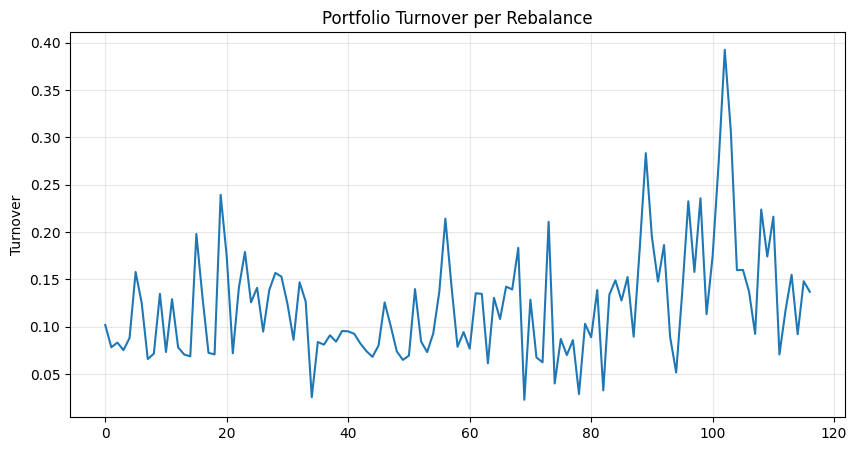


Average Turnover: 12.30%


In [20]:
# ==============================================================================
# TURNOVER ANALYSIS
# ==============================================================================

turnovers = []

for i in range(1, len(weight_history)):

    prev = weight_history[i-1]
    curr = weight_history[i]

    universe = prev.index.union(curr.index)

    prev = prev.reindex(universe).fillna(0)
    curr = curr.reindex(universe).fillna(0)

    turnover = (
        np.abs(curr - prev).sum()
        / 2
    )

    turnovers.append(turnover)

turnovers = pd.Series(turnovers)

print(turnovers.describe())

plt.figure(figsize=(10,5))

plt.plot(turnovers)

plt.title("Portfolio Turnover per Rebalance")

plt.ylabel("Turnover")

plt.grid(alpha=0.3)

plt.show()

print(
    f"\nAverage Turnover: {turnovers.mean():.2%}"
)

In [25]:
# ==============================================================================
# TRANSACTION COST ANALYSIS (504-DAY STRATEGY)
# ==============================================================================

BEST_LOOKBACK = 504

strategy_returns = all_results[BEST_LOOKBACK]

weight_history = all_weight_histories[BEST_LOOKBACK]

REBALANCE = 21

# --------------------------------------------------
# Turnover
# --------------------------------------------------

turnovers = []

for i in range(1, len(weight_history)):

    prev = weight_history[i-1]
    curr = weight_history[i]

    universe = prev.index.union(curr.index)

    prev = prev.reindex(universe).fillna(0)
    curr = curr.reindex(universe).fillna(0)

    turnover = (
        np.abs(curr - prev).sum()
        / 2
    )

    turnovers.append(turnover)

avg_turnover = np.mean(turnovers)

# --------------------------------------------------
# Cost Analysis
# --------------------------------------------------

cost_levels = [0.001, 0.0025, 0.005]

results = {}

for cost in cost_levels:

    after_cost = strategy_returns.copy()

    rebalance_dates = (
        strategy_returns.index[::REBALANCE]
    )

    for d in rebalance_dates:

        if d in after_cost.index:

            after_cost.loc[d] -= (
                avg_turnover * cost
            )

    results[
        f"{cost*100:.2f}% Cost"
    ] = performance_stats(
        after_cost
    )

pd.DataFrame(results).T.round(2)

,Years,Total Return (%),CAGR (%),Vol (%),Sharpe,Max DD (%),Calmar
0.10% Cost,11.07,1119.38,25.36,16.92,1.14,-31.89,0.80
0.25% Cost,11.07,1083.94,25.02,16.92,1.12,-31.91,0.78
0.50% Cost,11.07,1027.12,24.47,16.92,1.09,-31.93,0.77


Ticker
BAJFINANCE.NS    96
BAJAJFINSV.NS    69
BERGEPAINT.NS    69
PIDILITIND.NS    65
BRITANNIA.NS     63
SHREECEM.NS      58
HAVELLS.NS       55
EICHERMOT.NS     55
MARUTI.NS        53
BEL.NS           51
TITAN.NS         49
JSWSTEEL.NS      49
TECHM.NS         48
HCLTECH.NS       48
RELIANCE.NS      46
SUNPHARMA.NS     46
ASIANPAINT.NS    45
HINDUNILVR.NS    42
APOLLOHOSP.NS    40
INDUSINDBK.NS    40
dtype: int64


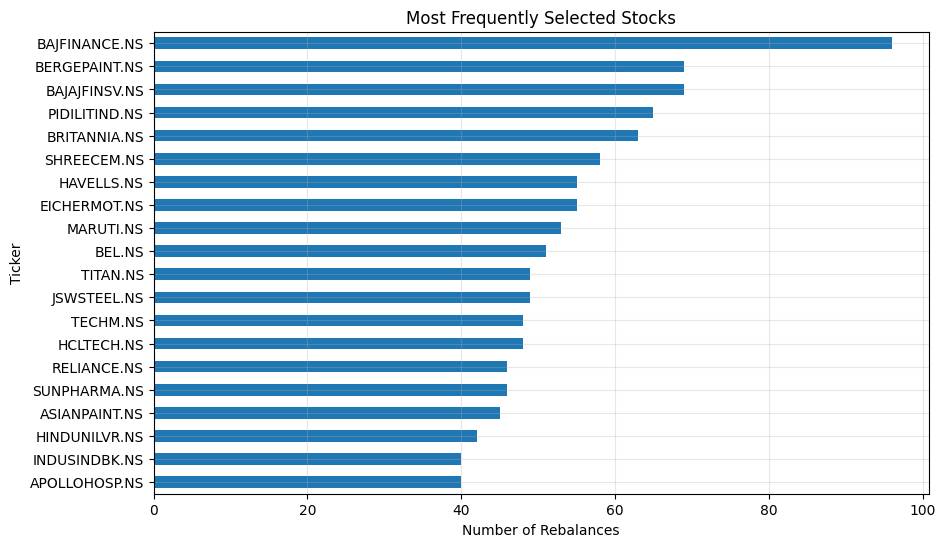

In [26]:
# ==============================================================================
# MOST FREQUENTLY SELECTED STOCKS
# ==============================================================================

weights_df = (
    pd.DataFrame(weight_history)
    .fillna(0)
)

selection_frequency = (
    weights_df.astype(bool)
    .sum()
    .sort_values(
        ascending=False
    )
)

print(
    selection_frequency.head(20)
)

plt.figure(figsize=(10,6))

selection_frequency\
    .head(20)\
    .sort_values()\
    .plot(kind="barh")

plt.title(
    "Most Frequently Selected Stocks"
)

plt.xlabel(
    "Number of Rebalances"
)

plt.grid(alpha=0.3)

plt.show()

In [27]:
sector_map = {

'HDFCBANK.NS':'Financials',
'ICICIBANK.NS':'Financials',
'SBIN.NS':'Financials',
'KOTAKBANK.NS':'Financials',
'AXISBANK.NS':'Financials',
'BAJFINANCE.NS':'Financials',

'TCS.NS':'IT',
'INFY.NS':'IT',
'HCLTECH.NS':'IT',
'WIPRO.NS':'IT',
'TECHM.NS':'IT',

'RELIANCE.NS':'Energy',
'ONGC.NS':'Energy',
'NTPC.NS':'Utilities',
'POWERGRID.NS':'Utilities',

'ITC.NS':'FMCG',
'HINDUNILVR.NS':'FMCG',
'NESTLEIND.NS':'FMCG',
'BRITANNIA.NS':'FMCG',

'SUNPHARMA.NS':'Pharma',
'DRREDDY.NS':'Pharma',
'CIPLA.NS':'Pharma',

'TITAN.NS':'Consumer',
'ASIANPAINT.NS':'Consumer',
'PIDILITIND.NS':'Consumer',

'MARUTI.NS':'Auto',
'M&M.NS':'Auto',
'EICHERMOT.NS':'Auto',

'TATASTEEL.NS':'Metals',
'JSWSTEEL.NS':'Metals',
'HINDALCO.NS':'Metals',

'LT.NS':'Industrials',
'ABB.NS':'Industrials',
'BEL.NS':'Industrials'
}

Utilities      0.017
Energy         0.027
Industrials    0.044
Pharma         0.046
Metals         0.052
Auto           0.067
Consumer       0.079
FMCG           0.100
Financials     0.101
IT             0.106
Other          0.363
dtype: float64


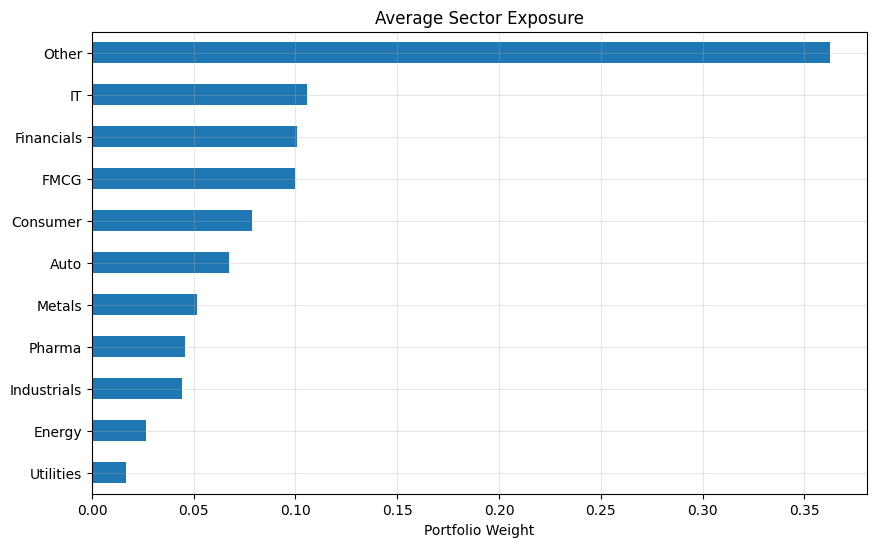

In [28]:
# ==============================================================================
# SECTOR EXPOSURE
# ==============================================================================

avg_weights = (
    pd.DataFrame(weight_history)
    .fillna(0)
    .mean()
)

sector_weights = {}

for stock, weight in avg_weights.items():

    sector = sector_map.get(
        stock,
        "Other"
    )

    sector_weights[sector] = (
        sector_weights.get(
            sector,
            0
        )
        + weight
    )

sector_weights = (
    pd.Series(sector_weights)
    .sort_values()
)

print(
    sector_weights.round(3)
)

plt.figure(figsize=(10,6))

sector_weights.plot(
    kind="barh"
)

plt.title(
    "Average Sector Exposure"
)

plt.xlabel(
    "Portfolio Weight"
)

plt.grid(alpha=0.3)

plt.show()